In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("energy_efficiency_data.csv")

df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [10]:
X = df.drop(["Heating_Load","Cooling_Load"], axis=1)

y = df["Cooling_Load"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [14]:
predictions = model.predict(X_test)

In [15]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 1.0604350649350647
R2 Score: 0.9683338660414131


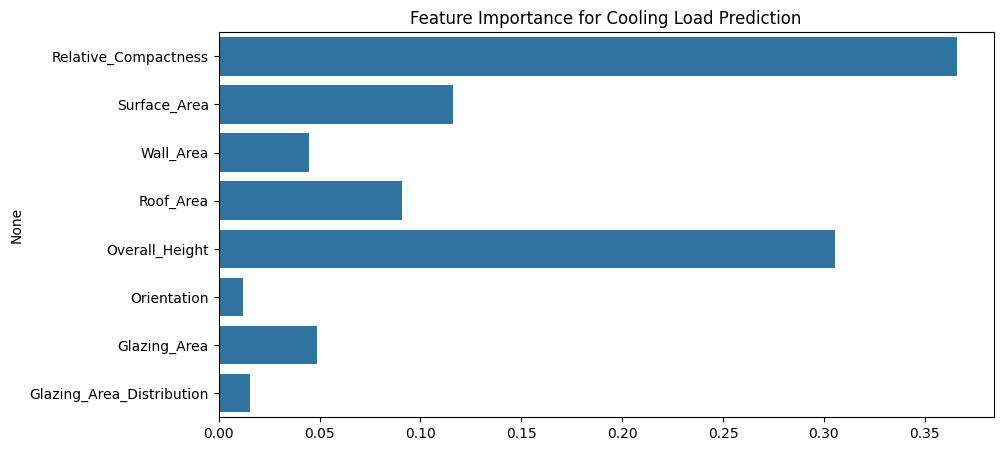

In [16]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(10,5))
sns.barplot(x=importance, y=features)

plt.title("Feature Importance for Cooling Load Prediction")
plt.show()

In [23]:
sample = [[
0.70,
700,
310,
220,
3.5,
3,
0.35,
4
]]

prediction = model.predict(sample)

cooling_load = prediction[0]

# baseline reference energy
baseline_energy = 26

# energy saving percentage
energy_saving = ((baseline_energy - cooling_load) / baseline_energy) * 100

# carbon emission calculation
carbon_emission = cooling_load * 0.82

print("Predicted Cooling Load:", round(cooling_load,2),"kWh")

if cooling_load > 20:
    temp = 25
else:
    temp = 26

print("Recommended AC Temperature:", temp,"°C")

print("Energy Saving Potential:", round(energy_saving,2),"%")

print("Estimated Carbon Emission:", round(carbon_emission,2),"kg CO2")

Predicted Cooling Load: 17.28 kWh
Recommended AC Temperature: 26 °C
Energy Saving Potential: 33.55 %
Estimated Carbon Emission: 14.17 kg CO2


c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


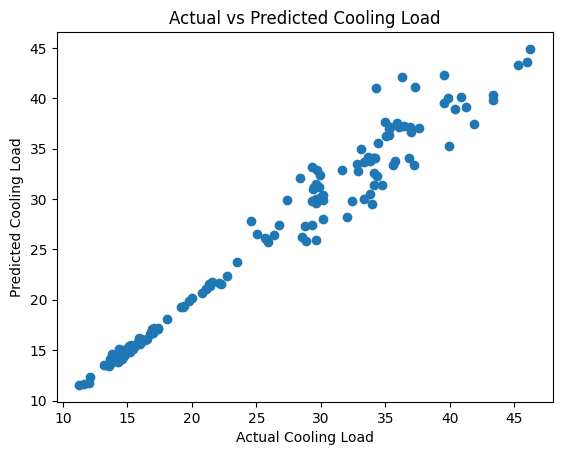

In [22]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual Cooling Load")
plt.ylabel("Predicted Cooling Load")
plt.title("Actual vs Predicted Cooling Load")
plt.show()